In [2]:
import os, sys, subprocess, pathlib, textwrap

# 1) Ir a la carpeta del proyecto (ajustada a tu ruta)
os.chdir(r"C:\Users\jaime\OneDrive - Universidad de la Sabana\Desktop\Jaime Pesca\MIT\GCLOG\Capstone project\SIMPAC-2024-311-main")
print("📁 Carpeta actual:", os.getcwd())

# 2) Verificar versión de Python (debe ser 3.10 por requisitos del proyecto)
print("🐍 Versión actual de Python:", sys.version)
if not sys.version.startswith("3.10"):
    print(textwrap.dedent("""\
        ⚠️ Este proyecto requiere Python 3.10.
        Crea/usa un entorno 3.10 y selecciónalo como kernel en VS Code:
          conda create -n deeppack3d python=3.10 -y
          conda activate deeppack3d
          python -m ipykernel install --user --name deeppack3d --display-name "Python 3.10 (deeppack3d)"
    """))

# 3) Instalar dependencias desde requirements.txt
req = pathlib.Path("requirements.txt")
assert req.exists(), "❌ No se encontró requirements.txt; verifica que estés en la carpeta del proyecto."
subprocess.check_call([sys.executable, "-m", "pip", "install", "-U", "pip", "wheel", "setuptools"])
subprocess.check_call([sys.executable, "-m", "pip", "install", "-r", str(req)])

# 4) (Opcional) Instalar el paquete en editable; si falla, seguimos igual
if pathlib.Path("setup.py").exists():
    try:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-e", "."])
        print("✅ Instalación editable OK.")
    except subprocess.CalledProcessError as e:
        print("⚠️ Instalación editable falló; continuamos sin -e .\nDetalle:", e)

# 5) Verificar input.txt y script principal
input_file = pathlib.Path("input.txt")
assert input_file.exists(), "❌ No se encontró input.txt en la carpeta actual."
main_script = pathlib.Path("deeppack3d.py")
assert main_script.exists(), "❌ No se encontró deeppack3d.py. Abre el README para confirmar el nombre del script."

# 6) Heurística BL (Best Lookahead) con lookahead=5 y datos desde archivo
cmd = [
    sys.executable,
    str(main_script),
    "bl", "5",               # método y lookahead
    "--n_iterations=-1",     # según README, para data=generated; aquí es indiferente
    "--data=file",           # leemos desde archivo
    f"--path={str(input_file)}",
    "--verbose=1"
]
print("\n🚀 Ejecutando heurística:\n", " ".join(cmd))
res = subprocess.run(cmd, capture_output=True, text=True)
print("\n----- STDOUT (Heurística) -----\n", res.stdout)
print("\n----- STDERR (Heurística) -----\n", res.stderr)

# 7) RL corto (3 episodios) como smoke test
cmd_rl = [
    sys.executable,
    str(main_script),
    "rl", "3",
    "--n_iterations=-1",
    "--data=file",
    f"--path={str(input_file)}",
    "--verbose=1"
]
print("\n🤖 Ejecutando RL corto:\n", " ".join(cmd_rl))
res_rl = subprocess.run(cmd_rl, capture_output=True, text=True)
print("\n----- STDOUT (RL) -----\n", res_rl.stdout)
print("\n----- STDERR (RL) -----\n", res_rl.stderr)


📁 Carpeta actual: C:\Users\jaime\OneDrive - Universidad de la Sabana\Desktop\Jaime Pesca\MIT\GCLOG\Capstone project\SIMPAC-2024-311-main
🐍 Versión actual de Python: 3.10.19 | packaged by Anaconda, Inc. | (main, Oct 21 2025, 16:41:31) [MSC v.1929 64 bit (AMD64)]
⚠️ Instalación editable falló; continuamos sin -e .
Detalle: Command '['c:\\Users\\jaime\\anaconda3\\envs\\deeppack3d\\python.exe', '-m', 'pip', 'install', '-e', '.']' returned non-zero exit status 1.

🚀 Ejecutando heurística:
 c:\Users\jaime\anaconda3\envs\deeppack3d\python.exe deeppack3d.py bl 5 --n_iterations=-1 --data=file --path=input.txt --verbose=1

----- STDOUT (Heurística) -----
 Testing with method "bl" and lookahead 5...
bin 0, loc: 0, space util: 63.68, packed items: 45

Episode 0, util: [63.68], used bins: 1, ep_reward: 34.77
bin 0, loc: 0, space util: 75.33, packed items: 41

Episode 1, util: [75.33], used bins: 1, ep_reward: 32.85
bin 0, loc: 0, space util: 63.05, packed items: 31

Episode 2, util: [63.05], used b

In [3]:
import os, sys, subprocess, pathlib, time, textwrap

# 📁 0) Ir a tu carpeta del proyecto
os.chdir(r"C:\Users\jaime\OneDrive - Universidad de la Sabana\Desktop\Jaime Pesca\MIT\GCLOG\Capstone project\SIMPAC-2024-311-main")
print("📁 Carpeta:", os.getcwd())
print("🐍 Python:", sys.version)

# 🔧 Configura aquí el lookahead (k) que quieres usar:
K = 5   # usa 5 porque ya tienes models\k=5.h5; también puedes poner 10 si quieres usar k=10.h5

main_script = pathlib.Path("deeppack3d.py")
input_file  = pathlib.Path("input.txt")
models_dir  = pathlib.Path("models"); models_dir.mkdir(exist_ok=True)
model_path  = models_dir / f"k={K}.h5"

assert main_script.exists(), "No encuentro deeppack3d.py"
assert input_file.exists(),  "No encuentro input.txt"

def run(cmd, title):
    print(f"\n🔹 {title}\n", " ".join(cmd))
    res = subprocess.run(cmd, capture_output=True, text=True)
    print("\n--- STDOUT ---\n", res.stdout)
    print("\n--- STDERR ---\n", res.stderr)
    return res

# 1) Si no existe el modelo para K, lo entrenamos corto (--train)
if not model_path.exists():
    print(f"⚙️ No existe {model_path}. Entrenando uno corto para k={K} ...")
    # Entrenamiento corto (batch pequeño). Aumenta episodios/tiempo si quieres mejor calidad.
    run([
        sys.executable, str(main_script),
        "rl", str(K),
        "--train",
        "--batch_size", "8",
        "--n_iterations=-1",
        "--data=file",
        f"--path={str(input_file)}",
        "--verbose=1"
    ], f"Entrenamiento RL (k={K})")
    time.sleep(2)

# 2) Ejecutar RL en modo inferencia para K (usa el modelo k=K.h5)
if model_path.exists():
    run([
        sys.executable, str(main_script),
        "rl", str(K),
        "--n_iterations=-1",
        "--data=file",
        f"--path={str(input_file)}",
        "--verbose=1"
    ], f"RL (inferencia) usando {model_path}")
else:
    print(f"❌ No se generó {model_path}. Vuelve a ejecutar con más pasos o cambia K a 5 o 10 (ya tienes esos modelos).")


📁 Carpeta: C:\Users\jaime\OneDrive - Universidad de la Sabana\Desktop\Jaime Pesca\MIT\GCLOG\Capstone project\SIMPAC-2024-311-main
🐍 Python: 3.10.19 | packaged by Anaconda, Inc. | (main, Oct 21 2025, 16:41:31) [MSC v.1929 64 bit (AMD64)]

🔹 RL (inferencia) usando models\k=5.h5
 c:\Users\jaime\anaconda3\envs\deeppack3d\python.exe deeppack3d.py rl 5 --n_iterations=-1 --data=file --path=input.txt --verbose=1

--- STDOUT ---
 Testing with method "rl" and lookahead 5...
bin 0, loc: 0, space util: 78.24, packed items: 53

Episode 0, util: [78.24], used bins: 1, ep_reward: 37.38, memory: None, eps: 0.00, loss: None, lr: None
bin 0, loc: 0, space util: 74.82, packed items: 42

Episode 1, util: [74.82], used bins: 1, ep_reward: 30.42, memory: None, eps: 0.00, loss: None, lr: None
bin 0, loc: 0, space util: 74.23, packed items: 34

Episode 2, util: [74.23], used bins: 1, ep_reward: 23.78, memory: None, eps: 0.00, loss: None, lr: None
bin 0, loc: 0, space util: 78.38, packed items: 54

Episode 3, 

####Método de graficar #1


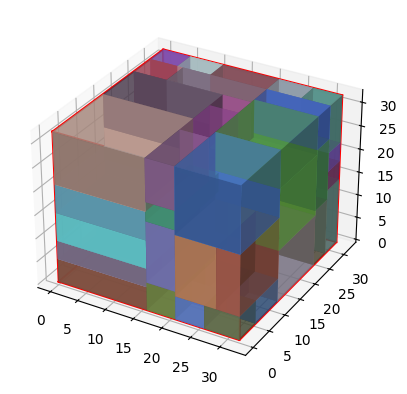

In [4]:
# Demo de visualización 3D programática
import os
os.chdir(r"C:\Users\jaime\OneDrive - Universidad de la Sabana\Desktop\Jaime Pesca\MIT\GCLOG\Capstone project\SIMPAC-2024-311-main")

from split_gen import gullotine_cut, reset_rng  # generador de particiones
from SpacePartitioner import SpacePartitioner   # packer con render()
reset_rng(42)

# Contenedor pequeño y rangos de tamaños de caja
container_size = (32, 32, 32)          # (W, H, D)
min_item, max_item = (4,4,4), (16,16,16)

# Genera y “empaqueta” particiones
packer = gullotine_cut(container_size, min_item, max_item, p=0.2, p_decay=0.9)

# Muestra las cajas colocadas (y contenedor en rojo)
fig = packer.render(free=False)  # usa free=True para ver espacios libres
fig


In [5]:
from SpacePartitioner import SpacePartitioner
from geometry import Cuboid

# Pallet/ULD: ancho, alto, fondo (elige unidades enteras coherentes con tus ítems)
PACK_SIZE = (120, 160, 100)
packer = SpacePartitioner(PACK_SIZE)

# Añadir bultos (w,h,d) en coordenadas (x,y,z) ya factibles:
items = [((0,0,0),(40,30,50)), ((40,0,0),(80,30,50))]  # (coord), (size)
for (x,y,z),(w,h,d) in items:
    packer.add(Cuboid(x,y,z,w,h,d))

# Mostrar ocupación y dibujo
print('Utilización:', packer.space_utilization())
fig = packer.render()  # o packer.render(free=True) para espacios libres


Utilización: 0.09375


In [7]:
from deeppack3d import deeppack3d

for result in deeppack3d('rl', 5, n_iterations=-1, data='file', path='./input.txt', verbose=0):
    if result is None:
        print('new bin')
        continue
    _, (x, y, z), (w, h, d), _ = result
    print(f'placing item ({w}, {h}, {d}) at ({x}, {y}, {z})')


placing item (10, 7, 8) at (0, 0, 0)
placing item (10, 7, 7) at (10, 0, 0)
placing item (10, 7, 6) at (20, 0, 0)
placing item (7, 7, 10) at (0, 0, 8)
placing item (7, 7, 6) at (0, 0, 18)
placing item (6, 8, 7) at (0, 7, 0)
placing item (7, 8, 8) at (0, 0, 24)
placing item (6, 7, 6) at (0, 15, 0)
placing item (8, 7, 8) at (10, 0, 7)
placing item (9, 6, 7) at (7, 0, 15)
placing item (6, 7, 8) at (16, 0, 15)
placing item (8, 7, 7) at (7, 7, 0)
placing item (6, 9, 8) at (18, 0, 7)
placing item (11, 7, 8) at (0, 7, 15)
placing item (8, 9, 6) at (15, 7, 0)
placing item (6, 7, 9) at (11, 7, 7)
placing item (9, 9, 6) at (0, 7, 7)
placing item (6, 6, 6) at (9, 14, 0)
placing item (6, 7, 9) at (17, 7, 15)
placing item (9, 10, 7) at (23, 7, 0)
placing item (6, 9, 6) at (17, 9, 7)
placing item (8, 9, 9) at (24, 0, 7)
placing item (9, 10, 6) at (23, 0, 16)
placing item (7, 8, 9) at (0, 8, 23)
placing item (10, 7, 8) at (7, 0, 24)
placing item (9, 8, 10) at (23, 0, 22)
placing item (8, 7, 6) at (23,

🧱 Bins detectados: 24
Bin 0: util=0.782  used_vol=25638  cont_vol=32768  size=(32, 32, 32)
Bin 1: util=0.748  used_vol=24518  cont_vol=32768  size=(32, 32, 32)
Bin 2: util=0.766  used_vol=24323  cont_vol=31744  size=(32, 32, 31)
Bin 3: util=0.784  used_vol=25685  cont_vol=32768  size=(32, 32, 32)
Bin 4: util=0.708  used_vol=23214  cont_vol=32768  size=(32, 32, 32)
Bin 5: util=0.768  used_vol=25153  cont_vol=32768  size=(32, 32, 32)
Bin 6: util=0.741  used_vol=24279  cont_vol=32768  size=(32, 32, 32)
Bin 7: util=0.660  used_vol=21619  cont_vol=32768  size=(32, 32, 32)
Bin 8: util=0.725  used_vol=23758  cont_vol=32768  size=(32, 32, 32)
Bin 9: util=0.680  used_vol=22271  cont_vol=32768  size=(32, 32, 32)
Bin 10: util=0.745  used_vol=24411  cont_vol=32768  size=(32, 32, 32)
Bin 11: util=0.712  used_vol=23326  cont_vol=32768  size=(32, 32, 32)
Bin 12: util=0.702  used_vol=22988  cont_vol=32768  size=(32, 32, 32)
Bin 13: util=0.729  used_vol=23903  cont_vol=32768  size=(32, 32, 32)
Bin 14: 

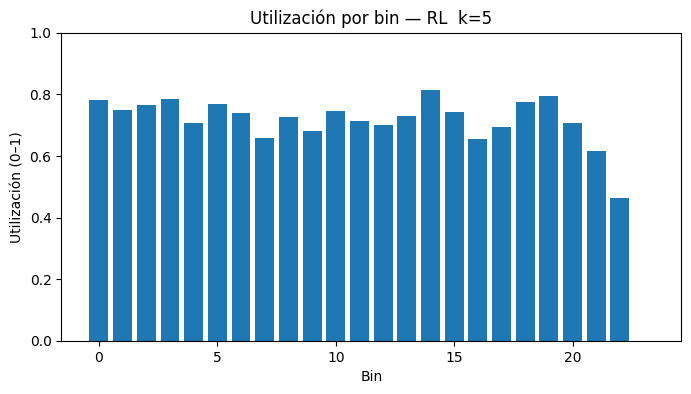

ValueError: not enough values to unpack (expected 5, got 0)

<Figure size 600x600 with 1 Axes>

In [8]:
# === Resumen por bin + gráficas (barras y 3D) ===
import os
os.chdir(r"C:\Users\jaime\OneDrive - Universidad de la Sabana\Desktop\Jaime Pesca\MIT\GCLOG\Capstone project\SIMPAC-2024-311-main")

from deeppack3d import deeppack3d
import math
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

# ---- Parámetros de corrida (mismos que tu bloque anterior) ----
METHOD = 'rl'
K = 5
DATA_MODE = 'file'          # 'file' o 'generated'
PATH = './input.txt'        # usado si DATA_MODE == 'file'
N_ITERS = 200               # usado si DATA_MODE == 'generated'
SEED = 42                   # opcional

# (Opcional) Si conoces el tamaño del contenedor/pallet (W,H,D), defínelo aquí:
# Ejemplo para un pallet estándar cualquiera: CONTAINER_SIZE = (120, 160, 100)
CONTAINER_SIZE = None   # <- deja None para inferir por bounding box del bin

# ---- Recolectar colocaciones por bin ----
bins = []               # lista de bins; cada bin es una lista de items
current_bin_items = None

gen_kwargs = dict(data=DATA_MODE, verbose=0)
if DATA_MODE == 'file':
    gen_kwargs['path'] = PATH
else:
    gen_kwargs['n_iterations'] = N_ITERS
    gen_kwargs['seed'] = SEED

for result in deeppack3d(METHOD, K, **gen_kwargs):
    if result is None:
        # empieza un nuevo bin
        current_bin_items = []
        bins.append(current_bin_items)
        continue
    bin_id, (x,y,z), (w,h,d), meta = result
    if current_bin_items is None:
        current_bin_items = []
        bins.append(current_bin_items)
    current_bin_items.append((x,y,z,w,h,d))

num_bins = len(bins)
print(f"🧱 Bins detectados: {num_bins}")

# ---- Utilidad por bin ----
def bin_utilization(items, container_size=None):
    """Devuelve (utilizacion, used_volume, container_volume, (W,H,D) usado)"""
    if not items:
        return 0.0, 0.0, 0.0, (0,0,0)
    used_volume = sum(w*h*d for (_,_,_,w,h,d) in items)
    if container_size is None:
        # inferir por bounding box de lo empacado
        max_x = max(x+w for (x,y,z,w,h,d) in items)
        max_y = max(y+h for (x,y,z,w,h,d) in items)
        max_z = max(z+d for (x,y,z,w,h,d) in items)
        W,H,D = max_x, max_y, max_z
    else:
        W,H,D = container_size
    container_volume = max(1, W*H*D)  # evita div/0
    return (used_volume / container_volume, used_volume, container_volume, (W,H,D))

utilizations = []
sizes_used = []
for i, items in enumerate(bins):
    u, used_v, cont_v, sz = bin_utilization(items, CONTAINER_SIZE)
    utilizations.append(u)
    sizes_used.append(sz)
    print(f"Bin {i}: util={u:.3f}  used_vol={used_v:.0f}  cont_vol={cont_v:.0f}  size={sz}")

# ---- Gráfico de barras: utilización por bin ----
plt.figure(figsize=(8,4))
plt.bar(range(len(utilizations)), utilizations)
plt.xlabel("Bin")
plt.ylabel("Utilización (0–1)")
plt.title(f"Utilización por bin — {METHOD.upper()}  k={K}")
plt.ylim(0, 1.0)
plt.show()

# ---- 3D del bin que elijas ----
BIN_TO_PLOT = 0  # cambia el índice para ver otro bin

def draw_cuboid(ax, x, y, z, w, h, d, alpha=0.35):
    X = [x, x+w]; Y = [y, y+h]; Z = [z, z+d]
    faces = [
        [(X[0],Y[0],Z[0]), (X[1],Y[0],Z[0]), (X[1],Y[1],Z[0]), (X[0],Y[1],Z[0])],
        [(X[0],Y[0],Z[1]), (X[1],Y[0],Z[1]), (X[1],Y[1],Z[1]), (X[0],Y[1],Z[1])],
        [(X[0],Y[0],Z[0]), (X[1],Y[0],Z[0]), (X[1],Y[0],Z[1]), (X[0],Y[0],Z[1])],
        [(X[0],Y[1],Z[0]), (X[1],Y[1],Z[0]), (X[1],Y[1],Z[1]), (X[0],Y[1],Z[1])],
        [(X[0],Y[0],Z[0]), (X[0],Y[1],Z[0]), (X[0],Y[1],Z[1]), (X[0],Y[0],Z[1])],
        [(X[1],Y[0],Z[0]), (X[1],Y[1],Z[0]), (X[1],Y[1],Z[1]), (X[1],Y[0],Z[1])],
    ]
    ax.add_collection3d(Poly3DCollection(faces, edgecolor='k', alpha=alpha))

def get_axis_limits(items, fallback=(1,1,1)):
    if not items: 
        return (0,1),(0,1),(0,1)
    max_x = max(x+w for (x,y,z,w,h,d) in items)
    max_y = max(y+h for (x,y,z,w,h,d) in items)
    max_z = max(z+d for (x,y,z,w,h,d) in items)
    return (0, max(max_x, fallback[0])), (0, max(max_y, fallback[1])), (0, max(max_z, fallback[2]))

items = bins[BIN_TO_PLOT] if BIN_TO_PLOT < num_bins else []
(W,H,D) = sizes_used[BIN_TO_PLOT] if BIN_TO_PLOT < num_bins else (1,1,1)

fig = plt.figure(figsize=(6,6))
ax = fig.add_subplot(111, projection='3d')

# dibuja contenedor como “wireframe” (opcional)
def draw_container_wire(ax, W,H,D):
    edges = [
        [(0,0,0),(W,0,0),(W,H,0),(0,H,0)],
        [(0,0,D),(W,0,D),(W,H,D),(0,H,D)],
        [(0,0,0),(0,0,D)], [(W,0,0),(W,0,D)],
        [(W,H,0),(W,H,D)], [(0,H,0),(0,H,D)],
    ]
    for poly in edges[:2]:
        ax.add_collection3d(Poly3DCollection([poly], facecolors='none', edgecolor='r', linewidths=1.2))
    # aristas verticales
    for e in edges[2:]:
        xs, ys, zs = zip(*e)
        ax.plot(xs, ys, zs, linewidth=1.2, color='r')

# dibuja contenedor inferido o indicado
draw_container_wire(ax, W,H,D)

# dibuja cajas (limita cantidad si hay muchas)
for (x,y,z,w,h,d) in items[:300]:
    draw_cuboid(ax, x,y,z,w,h,d, alpha=0.35)

# ejes
(xmin,xmax),(ymin,ymax),(zmin,zmax) = get_axis_limits(items, (W,H,D))
ax.set_xlim(xmin, xmax); ax.set_ylim(ymin, ymax); ax.set_zlim(zmin, zmax)
ax.set_xlabel('X'); ax.set_ylabel('Y'); ax.set_zlabel('Z')
ax.view_init(elev=20, azim=35)
plt.title(f"Bin {BIN_TO_PLOT} — util={utilizations[BIN_TO_PLOT]:.3f}")
plt.show()


Bins detectados: 24
Bin 0: util=0.782  used_vol=25638  cont_vol=32768  size=(32, 32, 32)
Bin 1: util=0.748  used_vol=24518  cont_vol=32768  size=(32, 32, 32)
Bin 2: util=0.766  used_vol=24323  cont_vol=31744  size=(32, 32, 31)
Bin 3: util=0.784  used_vol=25685  cont_vol=32768  size=(32, 32, 32)
Bin 4: util=0.708  used_vol=23214  cont_vol=32768  size=(32, 32, 32)
Bin 5: util=0.768  used_vol=25153  cont_vol=32768  size=(32, 32, 32)
Bin 6: util=0.741  used_vol=24279  cont_vol=32768  size=(32, 32, 32)
Bin 7: util=0.660  used_vol=21619  cont_vol=32768  size=(32, 32, 32)
Bin 8: util=0.725  used_vol=23758  cont_vol=32768  size=(32, 32, 32)
Bin 9: util=0.680  used_vol=22271  cont_vol=32768  size=(32, 32, 32)
Bin 10: util=0.745  used_vol=24411  cont_vol=32768  size=(32, 32, 32)
Bin 11: util=0.712  used_vol=23326  cont_vol=32768  size=(32, 32, 32)
Bin 12: util=0.702  used_vol=22988  cont_vol=32768  size=(32, 32, 32)
Bin 13: util=0.729  used_vol=23903  cont_vol=32768  size=(32, 32, 32)
Bin 14: ut

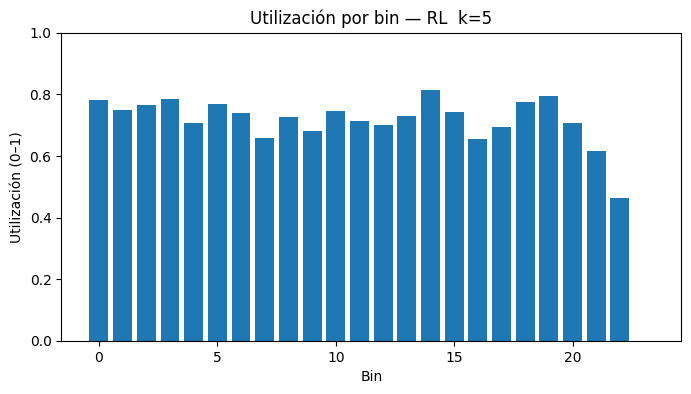

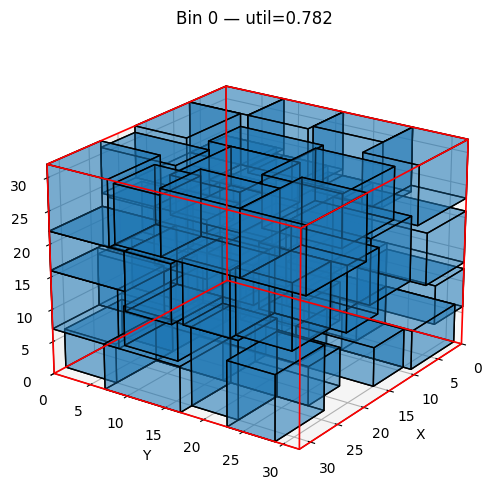

In [9]:
import os, sys, math, time
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection, Line3DCollection
from deeppack3d import deeppack3d

# === Parámetros de corrida (ajusta según lo que usaste antes) ===
METHOD = 'rl'         # 'rl' | 'bl' | 'baf' | 'bssf' | 'blsf'
K = 5
DATA_MODE = 'file'    # 'file' o 'generated'
PATH = './input.txt'  # usado si DATA_MODE == 'file'
N_ITERS = 80          # usado si DATA_MODE == 'generated'
SEED = 42             # opcional

# Si conoces W,H,D del contenedor, ponlos aquí; si no, deja None para inferir por bounding box
CONTAINER_SIZE = None  # ejemplo: (120, 160, 100)

# === 1) Recolectar colocaciones por bin con guardas ===
bins = []
cur = None
gen_kwargs = dict(data=DATA_MODE, verbose=0)
if DATA_MODE == 'file':
    gen_kwargs['path'] = PATH
else:
    gen_kwargs['n_iterations'] = N_ITERS
    gen_kwargs['seed'] = SEED

for result in deeppack3d(METHOD, K, **gen_kwargs):
    if result is None:
        cur = []
        bins.append(cur)
        continue
    bin_id, (x,y,z), (w,h,d), meta = result
    # Filtra cualquier caja degenerada (w/h/d <= 0) para evitar errores en el plot
    if w > 0 and h > 0 and d > 0:
        if cur is None:
            cur = []
            bins.append(cur)
        cur.append((x,y,z,w,h,d))

num_bins = len(bins)
print(f"Bins detectados: {num_bins}")

# === 2) Funciones auxiliares ===
def infer_size(items):
    if not items:
        return (1,1,1)
    mx = max(x+w for x,y,z,w,h,d in items)
    my = max(y+h for x,y,z,w,h,d in items)
    mz = max(z+d for x,y,z,w,h,d in items)
    # evita tamaño cero
    return (max(1, mx), max(1, my), max(1, mz))

def utilization(items, container_size=None):
    if not items:
        return 0.0, 0.0, 1.0, (1,1,1)
    used = sum(w*h*d for x,y,z,w,h,d in items)
    if container_size is None:
        W,H,D = infer_size(items)
    else:
        W,H,D = container_size
    total = max(1, W*H*D)
    return used/total, used, total, (W,H,D)

def container_edges(W,H,D):
    # aristas del paralelepípedo
    pts = [
        (0,0,0),(W,0,0),(W,H,0),(0,H,0),
        (0,0,D),(W,0,D),(W,H,D),(0,H,D)
    ]
    edges_idx = [
        (0,1),(1,2),(2,3),(3,0),   # base
        (4,5),(5,6),(6,7),(7,4),   # tapa
        (0,4),(1,5),(2,6),(3,7)    # verticales
    ]
    segs = [ [pts[i], pts[j]] for (i,j) in edges_idx ]
    return segs

def draw_cuboid(ax, x,y,z,w,h,d, alpha=0.35):
    # Crea caras sólo si w,h,d > 0
    X = [x, x+w]; Y = [y, y+h]; Z = [z, z+d]
    faces = [
        [(X[0],Y[0],Z[0]), (X[1],Y[0],Z[0]), (X[1],Y[1],Z[0]), (X[0],Y[1],Z[0])],
        [(X[0],Y[0],Z[1]), (X[1],Y[0],Z[1]), (X[1],Y[1],Z[1]), (X[0],Y[1],Z[1])],
        [(X[0],Y[0],Z[0]), (X[1],Y[0],Z[0]), (X[1],Y[0],Z[1]), (X[0],Y[0],Z[1])],
        [(X[0],Y[1],Z[0]), (X[1],Y[1],Z[0]), (X[1],Y[1],Z[1]), (X[0],Y[1],Z[1])],
        [(X[0],Y[0],Z[0]), (X[0],Y[1],Z[0]), (X[0],Y[1],Z[1]), (X[0],Y[0],Z[1])],
        [(X[1],Y[0],Z[0]), (X[1],Y[1],Z[0]), (X[1],Y[1],Z[1]), (X[1],Y[0],Z[1])],
    ]
    ax.add_collection3d(Poly3DCollection(faces, edgecolor='k', alpha=alpha))

# === 3) Utilización por bin (con guardas) ===
utils = []
sizes = []
for i, items in enumerate(bins):
    u, used, total, (W,H,D) = utilization(items, CONTAINER_SIZE)
    utils.append(u); sizes.append((W,H,D))
    print(f"Bin {i}: util={u:.3f}  used_vol={int(used)}  cont_vol={int(total)}  size={W,H,D}")

# === 4) Gráfico de barras de utilización ===
plt.figure(figsize=(8,4))
plt.bar(range(len(utils)), utils)
plt.xlabel("Bin")
plt.ylabel("Utilización (0–1)")
plt.ylim(0,1)
plt.title(f"Utilización por bin — {METHOD.upper()}  k={K}")
plt.show()

# === 5) 3D del primer bin NO vacío (evita errores de polígonos vacíos) ===
# Busca el primer bin con al menos 1 caja
bin_to_plot = next((i for i, items in enumerate(bins) if len(items) > 0), None)
if bin_to_plot is None:
    print("No hay bins con ítems para visualizar.")
else:
    items = bins[bin_to_plot]
    (W,H,D) = sizes[bin_to_plot]

    fig = plt.figure(figsize=(6,6))
    ax = fig.add_subplot(111, projection='3d')

    # Wireframe del contenedor con LINEAS (más robusto que polígonos vacíos)
    segs = container_edges(W,H,D)
    lc = Line3DCollection(segs, colors='r', linewidths=1.2)
    ax.add_collection3d(lc)

    # Dibuja hasta 300 cajas para no saturar
    for (x,y,z,w,h,d) in items[:300]:
        if w>0 and h>0 and d>0:
            draw_cuboid(ax, x,y,z,w,h,d, alpha=0.35)

    # Límites
    ax.set_xlim(0, max(1,W)); ax.set_ylim(0, max(1,H)); ax.set_zlim(0, max(1,D))
    ax.set_xlabel('X'); ax.set_ylabel('Y'); ax.set_zlabel('Z')
    ax.view_init(elev=22, azim=35)
    plt.title(f"Bin {bin_to_plot} — util={utils[bin_to_plot]:.3f}")
    plt.show()


## Segundas prueba

In [ ]:
from deeppack3d import deeppack3d

for result in deeppack3d('rl', 5, n_iterations=-1, data='file', path='./input.txt', verbose=0):
    if result is None:
        print('new bin')
        continue
    _, (x, y, z), (w, h, d), _ = result
    print(f'placing item ({w}, {h}, {d}) at ({x}, {y}, {z})')


In [ ]:
# 1) Ver qué archivo se está importando realmente
import importlib, inspect
import pack_with_pallet_plan as p
print("Usando módulo:", p.__file__)

# 2) Mostrar el código actual de pack_stage que tiene cargado Python
print("\n--- pack_stage cargado ---")
print(inspect.getsource(p.pack_stage))

# 3) Hotfix: si ves que todavía usa `item, (x,y,z), ...`, sobreescribimos la función en caliente
def _pack_stage_fixed(
    boxes_int, bin_size_int, qty, method=None, lookahead=32, seed=42, verbose=1
):
    from collections import Counter
    from agent import best_area_fit
    from env import MultiBinPackerEnv
    from conveyor import Conveyor
    from split_gen import reset_rng
    import numpy as np

    def normalize_item_order(item):
        return tuple(sorted(item, reverse=True))

    if method is None:
        method = best_area_fit

    reset_rng(seed)
    env = MultiBinPackerEnv(
        n_bins=1,
        size=bin_size_int,
        k=lookahead,
        max_bins=qty,
        replace="all",
        verbose=verbose > 1,
        use_rotate=True,
        use_skip=True,
    )
    env.conveyor = Conveyor(k=env.k, assigned_items=boxes_int).reset()

    from agent import HeuristicAgent
    agent = HeuristicAgent(method, env, verbose=verbose > 0, visualize=False)

    placements = []
    for result in agent.run(max_ep=1, verbose=verbose > 1):
        if result is None:
            continue
        # >>> AQUÍ ESTÁ LA CLAVE: el primer valor es el índice del bin <<<
        i_bin, (x, y, z), (w, h, d), split = result
        placements.append(((int(w), int(h), int(d)), (x, y, z), (w, h, d)))

    used_multiset = Counter(normalize_item_order(p0[0]) for p0 in placements)

    remaining = []
    for box in boxes_int:
        key = normalize_item_order(tuple(map(int, box)))
        if used_multiset[key] > 0:
            used_multiset[key] -= 1
        else:
            remaining.append(tuple(map(int, box)))

    used_bins = env.used_bins
    return placements, used_bins, remaining

# Sobrescribir la función en el módulo importado
p.pack_stage = _pack_stage_fixed
importlib.reload(p)  # asegura que el módulo vea la función asignada
print("\n[OK] Hotfix aplicado. Vuelve a correr run_plan.")


Usando módulo: C:\Users\jaime\OneDrive - Universidad de la Sabana\Desktop\Jaime Pesca\MIT\GCLOG\Capstone project\SIMPAC-2024-311-main\pack_with_pallet_plan.py

--- pack_stage cargado ---
def pack_stage(
    boxes_int: List[Tuple[int, int, int]],
    bin_size_int: Tuple[int, int, int],
    qty: int,
    method=best_area_fit,
    lookahead: int = 32,
    seed: int = 42,
    verbose: int = 1,
):
    """
    Empaca tantas cajas como sea posible dentro de 'qty' bins del tamaño indicado.
    Devuelve: placements, bins usados y las cajas restantes.
    """
    reset_rng(seed)
    env = MultiBinPackerEnv(
        n_bins=1,
        size=bin_size_int,
        k=lookahead,
        max_bins=qty,
        replace="all",
        verbose=verbose > 1,
        use_rotate=True,
        use_skip=True,
    )

    # Asignar los ítems exactos a empacar
    env.conveyor = Conveyor(k=env.k, assigned_items=boxes_int).reset()

    agent = HeuristicAgent(method, env, verbose=verbose > 0, visualize=False)
    plac

In [ ]:
# Parche seguro para SpacePartitioner.space_utilization
from SpacePartitioner import SpacePartitioner
import numpy as np

def _safe_space_utilization(self):
    used = sum(split.volume for split in self.splits)
    total = int(np.prod(self.size))
    # Evitar divisiones raras o volúmenes negativos por bugs de terceros
    if total <= 0:
        return 0.0
    # Clamp por seguridad
    util = used / total
    if util < 0: util = 0.0
    if util > 1: util = 1.0
    return util

# Aplicar el parche
SpacePartitioner.space_utilization = _safe_space_utilization
print("[OK] space_utilization parcheado (modo seguro).")


[OK] space_utilization parcheado (modo seguro).


In [ ]:
# Evitar np.array(...) en env.state() para no duplicar memoria
import types
import env as ENV

def _state_no_stack(self, step=False):
    if step or self._state is None:
        items = list(self.conveyor.peek())
        # Mantén h_maps como **lista** de arrays (sin np.array(...))
        h_maps = self._height_maps()  # lista de np.ndarray (uno por bin)
        actions = list(self.actions(items, h_maps, rotate=self.use_rotate, skip=self.use_skip))
        self._state = (items, h_maps, actions)
    return self._state

ENV.MultiBinPackerEnv.state = types.MethodType(_state_no_stack, ENV.MultiBinPackerEnv)
print("[OK] MultiBinPackerEnv.state sin np.array (no stack 3D).")


[OK] MultiBinPackerEnv.state sin np.array (no stack 3D).


### Pruebas nuevas

#### Preparar muestra de 10000 cajas

In [6]:
from deeppack3d import deeppack3d

DATA_PATH = r"C:\Users\jaime\OneDrive - Universidad de la Sabana\Desktop\Jaime Pesca\MIT\GCLOG\Capstone project\SIMPAC-2024-311-main\input_10k_cm_integer.txt"

# Consume el generador para ejecutar por completo
for _ in deeppack3d(
    method="bl",
    lookahead=5,
    data="file",
    path=DATA_PATH,
    verbose=1,
):
    pass

print("✅ Heurística BL finalizada con tus 10k cajas.")


Testing with method "bl" and lookahead 5...

=====the end of conveyor line=====

Used time: 0 seconds
Next items: [None, None, None, None, None]
Average space util: nan
Used bins: 0.0
✅ Heurística BL finalizada con tus 10k cajas.


c:\Users\jaime\anaconda3\envs\deeppack3d\lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\jaime\anaconda3\envs\deeppack3d\lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


In [ ]:
# Entrenamiento corto (smoke test): confirmamos que TF y la Q-net corren
for _ in deeppack3d(
    method="rl",
    lookahead=5,
    data="file",
    path=DATA_PATH,
    n_iterations=1,   # prueba corta
    train=True,       # usa Agent (TF)
    verbose=1
):
    pass

print("✅ Smoke test RL completado.")


In [ ]:
from deeppack3d import deeppack3d

# RL smoke test con datos generados para el bin 32x32x32 (por diseño del script)
for _ in deeppack3d(
    method="rl",
    lookahead=5,
    data="generated",   # << importante
    n_iterations=1,
    train=True,
    verbose=1
):
    pass


In [9]:
from env import MultiBinPackerEnv
from conveyor import FileConveyor
from agent import Agent
import numpy as np

DATA_PATH = r"input_boxes_sample_10000_cm_integer.txt"  # tu archivo en cm
BIN_SIZE  = (600, 250, 250)                     # ajusta a tu pallet/ULD real
LOOKAHEAD = 5

# 1) Construir entorno con tu BIN en cm
env = MultiBinPackerEnv(
    n_bins=1,
    max_bins=1,                # como en deeppack3d(train=True)
    size=BIN_SIZE,             # << clave: ya no es 32³
    k=LOOKAHEAD,
    prealloc_items=0,
    verbose=1,
    use_rotate=True,
    use_skip=True
)

# 2) Usar tu archivo como conveyor (w h d por línea)
env.conveyor = FileConveyor(k=env.k, path=DATA_PATH).reset()

# 3) Crear el agente RL (usa TF internamente)
agent = Agent(env, train=True, verbose=True, visualize=False, batch_size=32)

# 4) "Entrenamiento" corto: equivalencia al smoke test
#    agent.run() es un generador que va arrojando placements y None (nuevo bin)
steps = 0
for out in agent.run(max_ep=1, verbose=False, train=True):
    steps += 1

print("✅ RL smoke test con tu archivo y BIN real. Steps:", steps)


bin 0, loc: 0, space util: 52.05, packed items: 352

Episode 0, util: [52.05], used bins: 1, ep_reward: 205.44, memory: 352, eps: 1.00, loss: None, lr: 9.999999747378752e-06
✅ RL smoke test con tu archivo y BIN real. Steps: 353


In [ ]:
from env import MultiBinPackerEnv
from conveyor import FileConveyor
from agent import Agent
from pathlib import Path
import numpy as np, time, os

# === Parámetros ===
DATA_PATH = r"C:\Users\jaime\OneDrive - Universidad de la Sabana\Desktop\Jaime Pesca\MIT\GCLOG\Capstone project\SIMPAC-2024-311-main\input_10k_cm_integer.txt"
LOOKAHEAD = 5
BIN_SIZE = (600, 250, 250)   # <-- AJUSTA a tu contenedor real (w,h,d) en cm

# === Construir entorno con tu bin real ===
env = MultiBinPackerEnv(
    n_bins=1,
    max_bins=1,                 # como en el script original de training
    size=BIN_SIZE,              # clave: bin real, no 32^3
    k=LOOKAHEAD,
    prealloc_items=0,
    verbose=1,
    use_rotate=True,
    use_skip=True
)

# === Conveyor desde archivo (w h d por línea) ===
env.conveyor = FileConveyor(k=env.k, path=DATA_PATH).reset()

# === Agente RL (Q-network con TF) ===
agent = Agent(env, train=True, verbose=True, visualize=False, batch_size=32)  # :contentReference[oaicite:1]{index=1}

# === Entrenamiento corto "warmup" + más iteraciones ===
agent.eps = 1.0
N_ITER = 10   # súbelo luego (20, 50, 100...) según tu tiempo

for i in range(N_ITER):
    print(f"\nIteration {i}")
    t0 = time.time()
    for _ in agent.run(max_ep=100, verbose=False, train=True):  # genera placements y actualiza memoria/target net
        pass
    agent.eps = max(agent.eps * 0.95, 0.025)
    print("took", int(time.time()-t0), "s")

# === Métricas simples ===
utils = [u for utils, n_bins, ep_reward in agent.ep_history for u in utils]
avg_util = float(np.mean(utils)) if utils else 0.0
print(f"\nBins usados aprox: {agent.env.used_bins}, Utilización promedio: {avg_util:.3f}")

# === Guardar modelo donde deeppack3d lo busca en inferencia ===
models_dir = Path("./models"); models_dir.mkdir(exist_ok=True)
save_path = models_dir / f"k={LOOKAHEAD}.h5"
agent.q_net.save(str(save_path))
print("✅ Modelo guardado en:", save_path)


In [15]:
# 🔧 Parche permanente en tiempo de ejecución (sin editar el archivo todavía)
from env import MultiBinPackerEnv
import numpy as np

def p_map_fixed(self, i_bin, cuboid):
    x, y, z, w, h, d = cuboid
    W, H, D = self.packers[i_bin].size  # (width, height, depth)
    mask = np.zeros((D, W))             # ✅ (depth, width) para alinear con height_map
    mask[z:z + d, x:x + w] = h / H
    return mask

MultiBinPackerEnv.p_map = p_map_fixed
print("✅ MultiBinPackerEnv.p_map -> (D, W)")


✅ MultiBinPackerEnv.p_map -> (D, W)


In [16]:
# Debes tener ya creado tu 'env' con el BIN real
h_maps = env._height_maps()
print("height_map shape:", h_maps[0].shape)   # debería ser (D, W)

# Construye un cubo pequeño para probar la máscara de posición
amap = env.p_map(0, (0, 0, 0, 1, 1, 1))
print("p_map shape     :", amap.shape)        # debería ser (D, W)

assert h_maps[0].shape == amap.shape, "❌ Aún desalineado; revisa el parche."
print("✅ Shapes alineadas.")


height_map shape: (300, 244)
p_map shape     : (300, 244)
✅ Shapes alineadas.


In [17]:
# ==== ENTRENAMIENTO RL CON GPU (BIN = 244x318x300) ====

import os, time
import numpy as np
import tensorflow as tf

# --- (Opcional) Acelerar con mixed precision ---
# Si notas NaNs o inestabilidad, comenta estas 2 líneas.
from tensorflow.keras import mixed_precision
mixed_precision.set_global_policy("mixed_float16")

# --- Usar GPU si está disponible ---
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"✅ GPU detectada(s): {[d.name for d in gpus]}")
    except Exception as e:
        print("⚠️ No se pudo activar memory_growth:", e)
else:
    print("ℹ️ No hay GPU visible: se entrenará en CPU.")

# --- Importar componentes del proyecto ---
from env import MultiBinPackerEnv                      # entorno RL/acciones/recompensas  :contentReference[oaicite:0]{index=0}
from conveyor import Conveyor                          # inyectar items reales (assigned_items)  :contentReference[oaicite:1]{index=1}
from agent import Agent                                # agente con red Q (TF/Keras)  :contentReference[oaicite:2]{index=2}

# === Parámetros de tu caso ===
DATA_PATH  = r"C:\Users\jaime\OneDrive - Universidad de la Sabana\Desktop\Jaime Pesca\MIT\GCLOG\Capstone project\SIMPAC-2024-311-main\input_boxes_sample_10000_cm_integer.txt"
LOOKAHEAD  = 7                    # k
BIN_SIZE   = (244, 318, 300)      # pallet 96x125x118in -> cm

# Cargar tus 10k cajas (w,h,d) en cm enteros
items_all = np.loadtxt(DATA_PATH, dtype=int)
print("Cajas cargadas:", len(items_all))

# === Construir entorno con tu BIN real ===
env = MultiBinPackerEnv(
    n_bins=1,
    max_bins=1,                  # mismo patrón de training del script original
    size=BIN_SIZE,               # << clave: tu bin real
    k=LOOKAHEAD,
    prealloc_items=0,
    verbose=1,
    use_rotate=True,
    use_skip=True
)  # :contentReference[oaicite:3]{index=3}

# Inyectar tus items reales (sin aleatoriedad)
env.conveyor = Conveyor(k=env.k, assigned_items=items_all).reset()  # :contentReference[oaicite:4]{index=4}

# === Crear agente RL ===
agent = Agent(env, train=True, verbose=True, visualize=False, batch_size=32)  # red Q y target net  :contentReference[oaicite:5]{index=5}

# === Entrenamiento ===
agent.eps = 1.0
N_ITER   = 20      # súbelo después (50/100/200…) según tiempo
EPISODES = 100     # episodios por iteración interna del run

for i in range(N_ITER):
    print(f"\nIteration {i}")
    t0 = time.time()
    for _ in agent.run(max_ep=EPISODES, verbose=False, train=True):  # usa replay + target update internos
        pass
    agent.eps = max(agent.eps * 0.95, 0.025)  # mismo schedule que el script  :contentReference[oaicite:6]{index=6}
    print("took", int(time.time()-t0), "s")

# === Métricas simples de utilización ===
utils = [u for utils, n_bins, ep_reward in agent.ep_history for u in utils]
avg_util = float(np.mean(utils)) if utils else 0.0
print(f"\nBins usados aprox: {agent.env.used_bins}, Utilización promedio: {avg_util:.3f}")

# === Guardar modelo donde la API de alto nivel lo espera (./models/k=5.h5) ===
import pathlib
models_dir = pathlib.Path("./models"); models_dir.mkdir(exist_ok=True)
save_path = models_dir / f"k={LOOKAHEAD}.h5"
agent.q_net.save(str(save_path))
print("✅ Modelo guardado en:", save_path)


ℹ️ No hay GPU visible: se entrenará en CPU.
Cajas cargadas: 10000

Iteration 0
bin 0, loc: 0, space util: 51.35, packed items: 216

Episode 0, util: [51.35], used bins: 1, ep_reward: 128.85, memory: 216, eps: 1.00, loss: None, lr: 9.999999747378752e-06
bin 0, loc: 0, space util: 45.93, packed items: 191

Episode 1, util: [45.93], used bins: 1, ep_reward: 112.69, memory: 407, eps: 1.00, loss: None, lr: 9.999999747378752e-06
bin 0, loc: 0, space util: 54.58, packed items: 229

Episode 2, util: [54.58], used bins: 1, ep_reward: 132.17, memory: 636, eps: 1.00, loss: None, lr: 9.999999747378752e-06
bin 0, loc: 0, space util: 52.66, packed items: 222

Episode 3, util: [52.66], used bins: 1, ep_reward: 132.57, memory: 858, eps: 1.00, loss: None, lr: 9.999999747378752e-06
bin 0, loc: 0, space util: 50.48, packed items: 213

update model


ValueError: Input 0 of layer "model_10" is incompatible with the layer: expected shape=(None, 32, 32, 1), found shape=(9, 300, 244, 1)

In [ ]:
# Referencias de bins (pallets/ULD) con su cantidad y tamaño interno (w, h, d) en cm
REFERENCES = [
    {"name": "Main_96x125x118",        "qty": 23, "bin_size": (244, 318, 300)},
    {"name": "Main_96x125x96",         "qty": 5,  "bin_size": (244, 318, 244)},
    {"name": "Main_96x125x96_special", "qty": 2,  "bin_size": (244, 318, 244)},
    {"name": "Lower_96x125x64",        "qty": 9,  "bin_size": (244, 318, 163)},
    {"name": "Lower_60x92x64",         "qty": 2,  "bin_size": (152, 234, 163)},
]


In [ ]:
import numpy as np
DATA_PATH = r"C:\Users\jaime\OneDrive - Universidad de la Sabana\Desktop\Jaime Pesca\MIT\GCLOG\Capstone project\SIMPAC-2024-311-main\input_10k_cm_integer.txt"

items_all = np.loadtxt(DATA_PATH, dtype=int)
print("Cajas iniciales:", len(items_all))


In [ ]:
from collections import Counter
from pathlib import Path
import csv

def export_bin_csv(out_dir, ref_name, bin_index, placements):
    """
    placements: lista de (item_original, (x,y,z), (w,h,d), split)
    Crea un CSV con columnas: w,h,d,x,y,z
    """
    out_dir = Path(out_dir); out_dir.mkdir(parents=True, exist_ok=True)
    out_path = out_dir / f"{ref_name}_bin_{bin_index:03d}.csv"
    with out_path.open("w", newline="", encoding="utf-8") as f:
        writer = csv.writer(f)
        writer.writerow(["w", "h", "d", "x", "y", "z"])
        for item, (x,y,z), (w,h,d), _ in placements:
            writer.writerow([w,h,d,x,y,z])
    return out_path

def multiset_subtract(items, used_sizes):
    """
    items: np.ndarray (N,3) int
    used_sizes: lista de tuplas (w,h,d) de lo colocado
    Quita de 'items' exactamente las cantidades colocadas (match exacto).
    Devuelve: nuevo np.ndarray con las cajas restantes.
    """
    # Conteo de lo usado
    need = Counter(tuple(s) for s in used_sizes)
    if not need:
        return items

    remain = []
    for w,h,d in items.tolist():
        key = (w,h,d)
        if need.get(key, 0) > 0:
            need[key] -= 1  # esta caja se “consume”
        else:
            remain.append([w,h,d])
    return np.array(remain, dtype=int) if remain else np.zeros((0,3), dtype=int)


In [ ]:
from env import MultiBinPackerEnv
from conveyor import Conveyor
from agent import Agent, bottom_left, best_area_fit, best_short_side_fit, best_long_side_fit  # heurísticas originales  :contentReference[oaicite:2]{index=2}
import numpy as np

HEURISTICS = {
    "bl": bottom_left,
    "baf": best_area_fit,
    "bssf": best_short_side_fit,
    "blsf": best_long_side_fit,
}

def pack_one_bin(items_remaining, bin_size, lookahead=5, mode="rl", verbose=0, batch_size=32):
    """
    Empaca UN bin con 'items_remaining' y devuelve:
      placements: lista de colocaciones [(item,(x,y,z),(w,h,d),split), ...]
      items_restantes: np.ndarray (N,3) sin las cajas usadas en este bin

    Nota: usa MultiBinPackerEnv(n_bins=1, max_bins=1) para asegurar UN bin.
    """
    if len(items_remaining) == 0:
        return [], items_remaining

    # construir env por bin
    env = MultiBinPackerEnv(
        n_bins=1,
        max_bins=1,
        size=bin_size,
        k=lookahead,
        prealloc_items=0,
        verbose=(verbose>1),
        use_rotate=True,
        use_skip=True
    )  # :contentReference[oaicite:3]{index=3}

    # conveyor con items asignados (sin aleatoriedad)  :contentReference[oaicite:4]{index=4}
    env.conveyor = Conveyor(k=env.k, assigned_items=items_remaining).reset()

    placements = []

    if mode == "rl":
        agent = Agent(env, train=True, verbose=(verbose>0), visualize=False, batch_size=batch_size)  # RL-Q-net  :contentReference[oaicite:5]{index=5}
        # un episodio “corto” para llenar UN bin (max_ep lo deja igual que run de training)
        for out in agent.run(max_ep=1, verbose=False, train=True):
            if out is None:
                # fin del bin (env.max_bins=1)
                break
            placements.append(out)
    else:
        # heurístico (sin TF)
        heuristic = HEURISTICS[mode]
        # bucle manual equivalente a HeuristicAgent.run para un bin
        state = env.reset()
        while True:
            items, h_map, actions = state
            if len(actions) == 0:
                break
            action = heuristic(actions)
            next_state, reward, done = env.step(action)
            i, j, k = action
            placements.append(actions[i][j][k])
            if done:
                break
            state = next_state

    # Restar cajas usadas del pool
    used_sizes = [tpl[2] for tpl in placements]  # (w,h,d)
    items_restantes = multiset_subtract(items_remaining, used_sizes)

    return placements, items_restantes


In [ ]:
def run_multi_reference_pipeline(items_all, references, lookahead=5, mode="rl", out_dir="./bins_out", verbose=1):
    """
    Recorre las referencias en orden. Para cada referencia:
      - crea exactamente 'qty' bins de tamaño ref['bin_size']
      - empaca (RL o heurística) consumiendo cajas del pool
      - exporta CSV de cada bin
    Devuelve: dict con resumen + items restantes.
    """
    items_pool = np.array(items_all, dtype=int)
    summary = []
    bin_counter_global = 0

    for ref in references:
        name = ref["name"]
        qty  = int(ref["qty"])
        bsz  = tuple(ref["bin_size"])
        if verbose:
            print(f"\n=== Referencia: {name}  | qty={qty}  | bin={bsz} ===")

        for q in range(1, qty+1):
            if len(items_pool) == 0:
                if verbose: print("No quedan cajas. Se detiene.")
                break

            placements, items_pool = pack_one_bin(
                items_remaining=items_pool,
                bin_size=bsz,
                lookahead=lookahead,
                mode=mode,
                verbose=0
            )

            bin_counter_global += 1
            out_csv = export_bin_csv(out_dir, name, q, placements)
            if verbose:
                print(f"  Bin {q}/{qty}  -> colocadas: {len(placements)},   restantes: {len(items_pool)},  CSV: {out_csv}")

            summary.append({
                "ref": name,
                "bin_index": q,
                "placed": len(placements),
                "remaining_after": int(len(items_pool)),
                "csv": str(out_csv)
            })

    return {"summary": summary, "remaining_items": items_pool}


In [ ]:
result = run_multi_reference_pipeline(
    items_all=items_all,
    references=REFERENCES,
    lookahead=5,
    mode="rl",            # "rl" para Q-net; o "bl"/"baf"/"bssf"/"blsf" heurístico
    out_dir="./bins_out", # CSVs por bin
    verbose=1
)

print("\nResumen:")
for row in result["summary"][:5]:
    print(row)
print("... (total filas resumen:", len(result["summary"]), ")")
print("Cajas restantes sin empacar:", len(result["remaining_items"]))


## Nuevas pruebasssssssss sos


In [19]:
from pathlib import Path
import numpy as np
import tensorflow as tf

DATA_PATH = r"C:\Users\jaime\OneDrive - Universidad de la Sabana\Desktop\Jaime Pesca\MIT\GCLOG\Capstone project\SIMPAC-2024-311-main\input_boxes_sample_10000_cm_integer.txt"
items_all_cm = np.loadtxt(DATA_PATH, dtype=int)   # (w,h,d) en cm
print("Cajas:", len(items_all_cm))

# Bin “principal” para entrenar (el de 23 unidades)
TRAIN_BIN_CM = (244, 318, 300)  # (w,h,d) cm

# (Opcional) GPU y mixed precision
try:
    from tensorflow.keras import mixed_precision
    mixed_precision.set_global_policy("mixed_float16")
except Exception as e:
    print("Mixed precision no activada:", e)

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for g in gpus:
            tf.config.experimental.set_memory_growth(g, True)
        print("GPU detectada(s):", [d.name for d in gpus])
    except Exception as e:
        print("No se pudo setear memory_growth:", e)
else:
    print("Sin GPU visible (CPU).")


Cajas: 10000
Sin GPU visible (CPU).


In [20]:
from collections import Counter

GRID = 32  # tamaño fijo del grid para W y D; H también se normaliza en el valor

def to_grid(items_cm, bin_cm):
    """Escala (w,h,d) cm -> (w,h,d) en celdas 1..GRID."""
    W,H,D = bin_cm
    sx, sy, sz = GRID / W, GRID / H, GRID / D
    out = []
    for (w,h,d) in items_cm:
        wg = max(1, min(GRID, int(round(w * sx))))
        hg = max(1, min(GRID, int(round(h * sy))))
        dg = max(1, min(GRID, int(round(d * sz))))
        out.append((wg,hg,dg))
    return np.array(out, dtype=int)

def to_cm_placement(placement, bin_cm):
    """
    Convierte un placement (grid) -> cm para exportar:
      placement = (item,(x,y,z),(w,h,d),split)
    """
    (item,(x,y,z),(w,h,d),split) = placement
    W,H,D = bin_cm
    sx, sy, sz = W / GRID, H / GRID, D / GRID

    x_cm = int(round(x * sx))
    y_cm = int(round(y * sy))
    z_cm = int(round(z * sz))
    w_cm = int(round(w * sx))
    h_cm = int(round(h * sy))
    d_cm = int(round(d * sz))
    return (item, (x_cm,y_cm,z_cm), (w_cm,h_cm,d_cm), split)

def subtract_used(items_pool_cm, used_sizes_cm):
    """Resta del array items_pool_cm las cajas usadas (match exacto por tamaño)."""
    need = Counter(map(tuple, used_sizes_cm))
    keep = []
    for w,h,d in items_pool_cm:
        key = (w,h,d)
        if need.get(key,0) > 0:
            need[key] -= 1
        else:
            keep.append((w,h,d))
    return np.array(keep, dtype=int) if keep else np.zeros((0,3), dtype=int)


In [21]:
from env import MultiBinPackerEnv

def p_map_fixed(self, i_bin, cuboid):
    import numpy as np
    x, y, z, w, h, d = cuboid
    W, H, D = self.packers[i_bin].size
    mask = np.zeros((D, W))  # (depth, width)
    mask[z:z+d, x:x+w] = h / H
    return mask

MultiBinPackerEnv.p_map = p_map_fixed
print("✅ p_map asegurado como (D,W)")


✅ p_map asegurado como (D,W)


In [23]:
from env import MultiBinPackerEnv
from conveyor import Conveyor
from agent import Agent
import time

# 1) Escalar tus cajas a grid según el bin de entrenamiento
items_train_grid = to_grid(items_all_cm, TRAIN_BIN_CM)
print("Ejemplo item cm->grid:", items_all_cm[0], "->", items_train_grid[0])

# 2) Entorno 32³
env_train = MultiBinPackerEnv(
    n_bins=1, max_bins=1,
    size=(GRID, GRID, GRID),
    k=7, use_rotate=True, use_skip=True,
    prealloc_items=0, verbose=1
)  # :contentReference[oaicite:4]{index=4}

env_train.conveyor = Conveyor(k=env_train.k, assigned_items=items_train_grid).reset()  # :contentReference[oaicite:5]{index=5}

# 3) Agente RL
agent = Agent(env_train, train=True, verbose=True, visualize=False, batch_size=32)  # :contentReference[oaicite:6]{index=6}

# 4) Entrenamiento (arranca corto; luego sube)
agent.eps = 1.0
N_ITER, EPISODES = 5, 60   # súbelos cuando veas que corre bien

for i in range(N_ITER):
    print(f"\nIteration {i}")
    t0 = time.time()
    for _ in agent.run(max_ep=EPISODES, verbose=False, train=True):
        pass
    agent.eps = max(agent.eps * 0.95, 0.025)
    print("took", int(time.time()-t0), "s")

# (Opcional) Métrica simple
utils = [u for utils, n_bins, ep_reward in agent.ep_history for u in utils]
print("Utilización media (aprox):", np.mean(utils) if utils else None)

# 5) Guardar modelo
Path("models").mkdir(exist_ok=True)
MODEL_PATH = Path("models")/ "k=5_grid32.h5"
agent.q_net.save(str(MODEL_PATH))
print("✅ Modelo guardado en:", MODEL_PATH)


Ejemplo item cm->grid: [70 50 13] -> [9 5 1]

Iteration 0
bin 0, loc: 0, space util: 60.24, packed items: 271

Episode 0, util: [60.24], used bins: 1, ep_reward: 168.67, memory: 271, eps: 1.00, loss: None, lr: 9.999999747378752e-06
bin 0, loc: 0, space util: 59.47, packed items: 269

Episode 1, util: [59.47], used bins: 1, ep_reward: 170.79, memory: 540, eps: 1.00, loss: None, lr: 9.999999747378752e-06
bin 0, loc: 0, space util: 56.34, packed items: 257

Episode 2, util: [56.34], used bins: 1, ep_reward: 159.45, memory: 797, eps: 1.00, loss: None, lr: 9.999999747378752e-06


KeyboardInterrupt: 

In [ ]:
REFERENCES = [
    {"name": "Main_96x125x118",        "qty": 23, "bin_size": (244, 318, 300)},
    {"name": "Main_96x125x96",         "qty": 5,  "bin_size": (244, 318, 244)},
    {"name": "Main_96x125x96_special", "qty": 2,  "bin_size": (244, 318, 244)},
    {"name": "Lower_96x125x64",        "qty": 9,  "bin_size": (244, 318, 163)},
    {"name": "Lower_60x92x64",         "qty": 2,  "bin_size": (152, 234, 163)},
]

items_pool = items_all_cm.copy()
summary = []

for ref in REFERENCES:
    name = ref["name"]; qty = ref["qty"]; bin_cm = tuple(ref["bin_size"])
    print(f"\n=== {name} x {qty}  bin={bin_cm} ===")
    for i in range(1, qty+1):
        if len(items_pool)==0:
            print("Sin cajas restantes."); break
        placements_cm, items_pool = pack_one_bin_inference(items_pool, bin_cm, lookahead=5, model_path=MODEL_PATH)
        out_csv = f"out_{name}_bin_{i:03d}.csv"
        export_csv(placements_cm, out_csv)
        print(f"  Bin {i}/{qty} -> colocadas {len(placements_cm)} | restantes {len(items_pool)} | {out_csv}")
        summary.append({"ref":name,"bin":i,"placed":len(placements_cm),"remaining":len(items_pool),"csv":out_csv})

print("\nResumen (primeros 5):", summary[:5])
print("Restantes totales:", len(items_pool))


In [24]:
from pathlib import Path
import numpy as np
import tensorflow as tf

# === Ruta de tu archivo (cm) ===
DATA_PATH = r"C:\Users\jaime\OneDrive - Universidad de la Sabana\Desktop\Jaime Pesca\MIT\GCLOG\Capstone project\SIMPAC-2024-311-main\input_boxes_sample_10000_cm_integer.txt"

items_all_cm = np.loadtxt(DATA_PATH, dtype=int)
print("Cajas cargadas:", len(items_all_cm))
print("Ejemplo:", items_all_cm[0])


Cajas cargadas: 10000
Ejemplo: [70 50 13]


In [25]:
from collections import Counter

GRID = 32  # tamaño fijo del grid para la CNN

def to_grid(items_cm, bin_cm):
    W,H,D = bin_cm
    sx, sy, sz = GRID / W, GRID / H, GRID / D
    out = []
    for (w,h,d) in items_cm:
        wg = max(1, min(GRID, int(round(w * sx))))
        hg = max(1, min(GRID, int(round(h * sy))))
        dg = max(1, min(GRID, int(round(d * sz))))
        out.append((wg,hg,dg))
    return np.array(out, dtype=int)

def to_cm_placement(placement, bin_cm):
    (item,(x,y,z),(w,h,d),split) = placement
    W,H,D = bin_cm
    sx, sy, sz = W / GRID, H / GRID, D / GRID
    x_cm = int(round(x * sx)); y_cm = int(round(y * sy)); z_cm = int(round(z * sz))
    w_cm = int(round(w * sx)); h_cm = int(round(h * sy)); d_cm = int(round(d * sz))
    # clamp para no salirnos del bin por redondeos
    w_cm = min(w_cm, W - x_cm)
    h_cm = min(h_cm, H - y_cm)
    d_cm = min(d_cm, D - z_cm)
    return (item, (x_cm,y_cm,z_cm), (w_cm,h_cm,d_cm), split)

def subtract_used(items_pool_cm, used_sizes_cm):
    need = Counter(map(tuple, used_sizes_cm))
    keep = []
    for w,h,d in items_pool_cm:
        key = (w,h,d)
        if need.get(key,0) > 0:
            need[key] -= 1
        else:
            keep.append((w,h,d))
    return np.array(keep, dtype=int) if keep else np.zeros((0,3), dtype=int)


In [26]:
from env import MultiBinPackerEnv
import numpy as np

def p_map_fixed(self, i_bin, cuboid):
    x, y, z, w, h, d = cuboid
    W, H, D = self.packers[i_bin].size  # (width, height, depth)
    mask = np.zeros((D, W))             # (depth, width) — alinea con height_map
    mask[z:z+d, x:x+w] = h / H
    return mask

MultiBinPackerEnv.p_map = p_map_fixed
print("✅ p_map asegurado como (D,W)")


✅ p_map asegurado como (D,W)


In [ ]:
from env import MultiBinPackerEnv
from conveyor import Conveyor
from agent import Agent
import time
from tensorflow.keras import mixed_precision

# GPU opcional
try:
    mixed_precision.set_global_policy("mixed_float16")
except Exception:
    pass
for g in tf.config.list_physical_devices('GPU'):
    tf.config.experimental.set_memory_growth(g, True)

TRAIN_BIN_CM = (244, 318, 300)  # pallet 96×125×118 in → cm

# Escalar tus cajas a grid según el bin de entrenamiento
items_train_grid = to_grid(items_all_cm, TRAIN_BIN_CM)
print("Ejemplo cm->grid:", items_all_cm[0], "->", items_train_grid[0])

# Entorno 32³
env_train = MultiBinPackerEnv(
    n_bins=1, max_bins=1,
    size=(GRID, GRID, GRID),
    k=5, use_rotate=True, use_skip=True,
    prealloc_items=0, verbose=1
)
env_train.conveyor = Conveyor(k=env_train.k, assigned_items=items_train_grid).reset()

# Agente RL
agent = Agent(env_train, train=True, verbose=True, visualize=False, batch_size=32)

# Entrenamiento (empieza corto; luego súbelo)
agent.eps = 1.0
N_ITER, EPISODES = 5, 60
for i in range(N_ITER):
    print(f"\nIteration {i}")
    t0 = time.time()
    for _ in agent.run(max_ep=EPISODES, verbose=False, train=True):
        pass
    agent.eps = max(agent.eps * 0.95, 0.025)
    print("took", int(time.time()-t0), "s")

# Guardar modelo
Path("models").mkdir(exist_ok=True)
MODEL_PATH = Path("models") / "k=5_grid32.h5"
agent.q_net.save(str(MODEL_PATH))
print("✅ Modelo guardado en:", MODEL_PATH)


Ejemplo cm->grid: [70 50 13] -> [9 5 1]

Iteration 0
bin 0, loc: 0, space util: 58.65, packed items: 264

Episode 0, util: [58.65], used bins: 1, ep_reward: 161.29, memory: 264, eps: 1.00, loss: None, lr: 9.999999747378752e-06
bin 0, loc: 0, space util: 58.29, packed items: 263

Episode 1, util: [58.29], used bins: 1, ep_reward: 166.48, memory: 527, eps: 1.00, loss: None, lr: 9.999999747378752e-06
bin 0, loc: 0, space util: 57.17, packed items: 259

Episode 2, util: [57.17], used bins: 1, ep_reward: 160.47, memory: 786, eps: 1.00, loss: None, lr: 9.999999747378752e-06
bin 0, loc: 0, space util: 64.17, packed items: 286

update model
Episode 3, util: [64.17], used bins: 1, ep_reward: 180.56, memory: 1072, eps: 1.00, loss: 9.7734375, lr: 9.999999747378752e-06
bin 0, loc: 0, space util: 57.33, packed items: 259

update model
Episode 4, util: [57.33], used bins: 1, ep_reward: 161.16, memory: 1331, eps: 1.00, loss: 2.67578125, lr: 9.999999747378752e-06
bin 0, loc: 0, space util: 58.36, pack

In [ ]:
MODEL_PATH = "models/k=5_grid32.h5"


In [ ]:
GRID = 32

def to_grid(items_cm, bin_cm):
    W,H,D = bin_cm
    sx, sy, sz = GRID / W, GRID / H, GRID / D
    out = []
    for (w,h,d) in items_cm:
        wg = max(1, min(GRID, int(round(w * sx))))
        hg = max(1, min(GRID, int(round(h * sy))))
        dg = max(1, min(GRID, int(round(d * sz))))
        out.append((wg,hg,dg))
    return np.array(out, dtype=int)

def to_cm_placement(placement, bin_cm):
    (item,(x,y,z),(w,h,d),split) = placement
    W,H,D = bin_cm
    sx, sy, sz = W / GRID, H / GRID, D / GRID
    x_cm = int(round(x * sx))
    y_cm = int(round(y * sy))
    z_cm = int(round(z * sz))
    w_cm = int(round(w * sx))
    h_cm = int(round(h * sy))
    d_cm = int(round(d * sz))
    # Clamp
    w_cm = min(w_cm, W - x_cm)
    h_cm = min(h_cm, H - y_cm)
    d_cm = min(d_cm, D - z_cm)
    return (item,(x_cm,y_cm,z_cm),(w_cm,h_cm,d_cm),split)


In [ ]:
import numpy as np

DATA_PATH = r"input_boxes_sample_10000_cm_integer.txt"
items_all_cm = np.loadtxt(DATA_PATH, dtype=int)
print("Cajas cargadas:", len(items_all_cm))


In [ ]:
BIN_REAL_CM = (244, 318, 300)


In [ ]:
from tensorflow.keras.models import load_model
from agent import Agent
from env import MultiBinPackerEnv
from conveyor import Conveyor

MODEL_PATH = "models/k=5_grid32.h5"

q_net = load_model(MODEL_PATH, compile=False)
print("✅ Modelo cargado")


In [ ]:
def pack_one_bin_inference(items_pool_cm, bin_cm, model, lookahead=5, verbose=1):
    # 1. Convertimos las cajas a grid
    items_grid = to_grid(items_pool_cm, bin_cm)

    # 2. Creamos ambiente 32³
    env_inf = MultiBinPackerEnv(
        n_bins=1, max_bins=1,
        size=(GRID,GRID,GRID),
        k=lookahead,
        use_rotate=True, use_skip=True,
        verbose=(verbose>1)
    )
    env_inf.conveyor = Conveyor(k=env_inf.k, assigned_items=items_grid).reset()

    # 3. Agente en inferencia
    agent_inf = Agent(env_inf, train=False, verbose=False, visualize=False, batch_size=32)
    agent_inf.q_net = model

    # 4. Ejecutar un episodio
    placements_grid = []
    for out in agent_inf.run(max_ep=1, verbose=False, train=False):
        if out is None:
            break
        placements_grid.append(out)

    # 5. Convertir cada colocación a centímetros reales
    placements_cm = [to_cm_placement(p, bin_cm) for p in placements_grid]

    # 6. Remover del dataset las cajas ya usadas
    used_sizes_cm = [p[2] for p in placements_cm]
    remaining_cm = subtract_used(items_pool_cm, used_sizes_cm)

    return placements_cm, remaining_cm


In [ ]:
placements_cm, remaining = pack_one_bin_inference(
    items_pool_cm=items_all_cm,
    bin_cm=BIN_REAL_CM,
    model=q_net,
    lookahead=5
)

print("✅ Cajas colocadas:", len(placements_cm))
print("✅ Restantes:", len(remaining))


In [ ]:
import csv

def export_csv(placements_cm, out_csv):
    with open(out_csv, "w", newline="", encoding="utf-8") as f:
        w = csv.writer(f)
        w.writerow(["item_index","x","y","z","w","h","d"])
        for item,(x,y,z),(w_,h_,d_),_ in placements_cm:
            w.writerow([item,x,y,z,w_,h_,d_])

export_csv(placements_cm, "pallet_244x318x300.csv")
print("✅ CSV generado: pallet_244x318x300.csv")


In [ ]:
# ============================================
# Rutina MULTI-REFERENCIA (INFERENCIA RL GRID32 → CM)
# ============================================

import os
from pathlib import Path
import numpy as np
import csv

# --------------------------
# 0) PARAMETROS PRINCIPALES
# --------------------------
# Ruta a tu archivo real de 10k cajas (cm enteros, columnas: w h d)
DATA_PATH  = r"C:\Users\jaime\OneDrive - Universidad de la Sabana\Desktop\Jaime Pesca\MIT\GCLOG\Capstone project\SIMPAC-2024-311-main\input_boxes_sample_10000_cm_integer.txt"
# Ruta del modelo entrenado (guardado en la fase de entrenamiento)
MODEL_PATH = r"C:\Users\jaime\OneDrive - Universidad de la Sabana\Desktop\Jaime Pesca\MIT\GCLOG\Capstone project\SIMPAC-2024-311-main\models\k=5_grid32.h5"
# Carpeta de salida para CSVs
OUT_DIR    = r"C:\Users\jaime\OneDrive - Universidad de la Sabana\Desktop\Jaime Pesca\MIT\GCLOG\Capstone project\SIMPAC-2024-311-main\bins_out"
Path(OUT_DIR).mkdir(parents=True, exist_ok=True)

# Tus referencias (en el orden indicado)
REFERENCES = [
    {"name": "Main_96x125x118",        "qty": 23, "bin_size": (244, 318, 300)},
    {"name": "Main_96x125x96",         "qty": 5,  "bin_size": (244, 318, 244)},
    {"name": "Main_96x125x96_special", "qty": 2,  "bin_size": (244, 318, 244)},
    {"name": "Lower_96x125x64",        "qty": 9,  "bin_size": (244, 318, 163)},
    {"name": "Lower_60x92x64",         "qty": 2,  "bin_size": (152, 234, 163)},
]

# Lookahead (k) que usaste al entrenar
LOOKAHEAD = 5
GRID = 32

# --------------------------
# 1) UTILIDADES DE ESCALADO
# --------------------------
from collections import Counter

def to_grid(items_cm, bin_cm, grid=GRID, margin_cells=0):
    """
    Escala (w,h,d) cm -> grid (w,h,d) en celdas (1..GRID).
    margin_cells: si quieres holgura, resta celdas (p.ej. 1) en w/d/h (no negativo).
    """
    W,H,D = bin_cm
    sx, sy, sz = grid / W, grid / H, grid / D
    out = []
    for (w,h,d) in items_cm:
        wg = max(1, min(grid, int(round(w * sx)) - margin_cells))
        hg = max(1, min(grid, int(round(h * sy)) - margin_cells))
        dg = max(1, min(grid, int(round(d * sz)) - margin_cells))
        out.append((wg,hg,dg))
    return np.array(out, dtype=int)

def to_cm_placement(placement, bin_cm, grid=GRID):
    """
    Convierte un placement (grid) -> cm, con "clamp" para no salir del bin por redondeos.
    placement = (item,(x,y,z),(w,h,d),split)
    """
    (item,(x,y,z),(w,h,d),split) = placement
    W,H,D = bin_cm
    sx, sy, sz = W / grid, H / grid, D / grid
    x_cm = int(round(x * sx)); y_cm = int(round(y * sy)); z_cm = int(round(z * sz))
    w_cm = int(round(w * sx)); h_cm = int(round(h * sy)); d_cm = int(round(d * sz))
    # clamp para no exceder bordes por redondeo
    w_cm = min(w_cm, W - x_cm)
    h_cm = min(h_cm, H - y_cm)
    d_cm = min(d_cm, D - z_cm)
    return (item, (x_cm,y_cm,z_cm), (w_cm,h_cm,d_cm), split)

def subtract_used(items_pool_cm, used_sizes_cm):
    """
    Quita del inventario 'items_pool_cm' las cajas cuyos tamaños aparecen en used_sizes_cm.
    (match exacto w,h,d)
    """
    need = Counter(map(tuple, used_sizes_cm))
    keep = []
    for w,h,d in items_pool_cm:
        key = (w,h,d)
        if need.get(key, 0) > 0:
            need[key] -= 1
        else:
            keep.append((w,h,d))
    return np.array(keep, dtype=int) if keep else np.zeros((0,3), dtype=int)

def export_bin_csv(out_dir, ref_name, bin_index, placements_cm):
    """
    Crea CSV con columnas: w,h,d,x,y,z en centímetros reales.
    """
    out_path = Path(out_dir) / f"{ref_name}_bin_{bin_index:03d}.csv"
    with out_path.open("w", newline="", encoding="utf-8") as f:
        wtr = csv.writer(f)
        wtr.writerow(["w","h","d","x","y","z"])
        for _,(x,y,z),(w,h,d),_ in placements_cm:
            wtr.writerow([w,h,d,x,y,z])
    return str(out_path)

# --------------------------
# 2) PARCHE DE p_map (alinear shapes)
# --------------------------
from env import MultiBinPackerEnv
import numpy as np

def p_map_fixed(self, i_bin, cuboid):
    x, y, z, w, h, d = cuboid
    W, H, D = self.packers[i_bin].size  # (width, height, depth)
    mask = np.zeros((D, W))             # (depth, width), igual que height_map
    mask[z:z+d, x:x+w] = h / H
    return mask

MultiBinPackerEnv.p_map = p_map_fixed  # parche a nivel de clase
print("✅ p_map -> (D,W) listo")

# --------------------------
# 3) CARGA DE DATOS Y MODELO
# --------------------------
assert Path(DATA_PATH).exists(), f"No se encontró DATA_PATH: {DATA_PATH}"
items_pool = np.loadtxt(DATA_PATH, dtype=int)
print("Cajas cargadas:", len(items_pool))

from tensorflow.keras.models import load_model
from agent import Agent
from conveyor import Conveyor
from env import MultiBinPackerEnv

assert Path(MODEL_PATH).exists(), f"No se encontró MODEL_PATH: {MODEL_PATH}"
q_net = load_model(MODEL_PATH, compile=False)
print("✅ Modelo cargado:", MODEL_PATH)

# --------------------------
# 4) INFERENCIA PARA UN BIN (helper)
# --------------------------
def pack_one_bin_inference(items_pool_cm, bin_cm, model, lookahead=LOOKAHEAD, margin_cells=0, verbose=0):
    """
    Empaca UN bin:
      - escala items al grid (con posible holgura margin_cells)
      - ejecuta RL en env 32³ (inferencias)
      - desescala placements a cm
      - resta las cajas usadas del pool
    Devuelve: placements_cm, items_rest_cm
    """
    # Escalar pool al grid de este bin
    items_grid = to_grid(items_pool_cm, bin_cm, GRID, margin_cells=margin_cells)

    # Env 32³ para inferencia
    env_inf = MultiBinPackerEnv(
        n_bins=1, max_bins=1,
        size=(GRID, GRID, GRID),
        k=lookahead, use_rotate=True, use_skip=True,
        prealloc_items=0, verbose=(verbose>1)
    )
    env_inf.conveyor = Conveyor(k=env_inf.k, assigned_items=items_grid).reset()

    # Agente en inferencia
    agent_inf = Agent(env_inf, train=False, verbose=False, visualize=False, batch_size=32)
    agent_inf.q_net = model

    placements_grid = []
    for out in agent_inf.run(max_ep=1, verbose=False, train=False):
        if out is None:
            break
        placements_grid.append(out)

    # Desescalar a cm
    placements_cm = [to_cm_placement(p, bin_cm, GRID) for p in placements_grid]

    # Quitar cajas usadas del pool (por tamaño en cm)
    used_sizes_cm = [p[2] for p in placements_cm]
    items_rest_cm = subtract_used(items_pool_cm, used_sizes_cm)

    return placements_cm, items_rest_cm

# --------------------------
# 5) PIPELINE MULTI-REFERENCIA
# --------------------------
summary = []
for ref in REFERENCES:
    name = ref["name"]
    qty  = int(ref["qty"])
    bin_cm = tuple(ref["bin_size"])

    print(f"\n=== {name} | qty={qty} | bin={bin_cm} ===")
    for i in range(1, qty+1):
        if len(items_pool) == 0:
            print("No quedan cajas. Se detiene.")
            break

        placements_cm, items_pool = pack_one_bin_inference(
            items_pool_cm=items_pool,
            bin_cm=bin_cm,
            model=q_net,
            lookahead=LOOKAHEAD,
            margin_cells=0,     # si necesitas holgura, prueba 1
            verbose=0
        )

        out_csv = export_bin_csv(OUT_DIR, name, i, placements_cm)
        print(f"  Bin {i}/{qty} -> colocadas: {len(placements_cm)} | restantes: {len(items_pool)} | {out_csv}")
        summary.append({
            "ref": name,
            "bin": i,
            "placed": len(placements_cm),
            "remaining": int(len(items_pool)),
            "csv": out_csv
        })

print("\n✅ Rutina finalizada.")
print("Bins generados:", len(summary))
print("Cajas restantes sin empacar:", len(items_pool))
print("Ejemplo resumen:", summary[:3])


In [ ]:
from tensorflow.keras.models import load_model
from env import MultiBinPackerEnv
from conveyor import Conveyor
from agent import Agent
import csv

def export_csv(placements_cm, out_csv):
    with open(out_csv, "w", newline="", encoding="utf-8") as f:
        wtr = csv.writer(f); wtr.writerow(["w","h","d","x","y","z"])
        for _,(x,y,z),(w,h,d),_ in placements_cm:
            wtr.writerow([w,h,d,x,y,z])

def pack_one_bin_inference(items_pool_cm, bin_cm, lookahead=5, model_path=MODEL_PATH, verbose=1):
    items_grid = to_grid(items_pool_cm, bin_cm)
    env_inf = MultiBinPackerEnv(n_bins=1, max_bins=1, size=(GRID,GRID,GRID),
                                k=lookahead, use_rotate=True, use_skip=True, verbose=(verbose>1))
    env_inf.conveyor = Conveyor(k=env_inf.k, assigned_items=items_grid).reset()
    agent_inf = Agent(env_inf, train=False, verbose=False, visualize=False, batch_size=32)
    agent_inf.q_net = load_model(str(model_path), compile=False)

    placements_grid = []
    for out in agent_inf.run(max_ep=1, verbose=False, train=False):
        if out is None:
            break
        placements_grid.append(out)

    placements_cm = [to_cm_placement(p, bin_cm) for p in placements_grid]
    used_sizes_cm = [p[2] for p in placements_cm]
    items_rest_cm = subtract_used(items_pool_cm, used_sizes_cm)
    return placements_cm, items_rest_cm

# Empacar 1 bin del tipo “23 veces”
BIN_REAL = TRAIN_BIN_CM
placements_cm, remaining_cm = pack_one_bin_inference(items_all_cm, BIN_REAL, lookahead=5, model_path=MODEL_PATH)
print("Colocadas:", len(placements_cm), " | Restantes:", len(remaining_cm))

out_csv = "bin_real_244x318x300.csv"
export_csv(placements_cm, out_csv)
print("CSV generado:", out_csv)
